# Financial Performance Analysis of Public Companies

This notebook uses Python and Yahoo Finance data to clean, analyze, and visualize stock prices of public companies and present conclusions.

## 1. Environment Setup

If the current kernel does not have the dependencies installed, run the cell below first. It is also safe to run again if they are already installed.

In [50]:
# %pip install -r requirements.txt

In [51]:
from datetime import datetime, timedelta
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
# ==================== Configure matplotlib font settings ====================
# Set the seaborn theme first (this resets some matplotlib parameters)
sns.set_theme(style='whitegrid')
# Apply font settings after the seaborn theme to avoid overrides
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'Arial Unicode MS', 'DejaVu Sans']
# Fix the issue where the minus sign '-' may render incorrectly
plt.rcParams['axes.unicode_minus'] = False
# ====================================================================

Path('figures').mkdir(exist_ok=True)
print('Environment setup complete. The figures directory is ready.')

Environment setup complete. The figures directory is ready.


## 2. Parameter Settings

In [52]:
stock_list = ['AAPL', 'MSFT', 'GOOGL']
end_date = datetime.now()
start_date = end_date - timedelta(days=365 * 2)
risk_free_rate = 0.02

print(f'Stocks analyzed: {", ".join(stock_list)}')
print(f'Analysis period: {start_date:%Y-%m-%d} to {end_date:%Y-%m-%d}')
print(f'Assumed risk-free rate: {risk_free_rate:.0%}')

Stocks analyzed: AAPL, MSFT, GOOGL
Analysis period: 2024-04-13 to 2026-04-13
Assumed risk-free rate: 2%


## 3. Data Download and Cleaning

In [53]:
def download_close_prices(tickers, start, end):
    """Download closing prices and handle both single-ticker and multi-ticker return formats."""
    import time

    max_retries = 3
    last_error = None

    for attempt in range(max_retries):
        try:
            if attempt > 0:
                print(f"Attempt {attempt + 1}...")
                time.sleep(5)

            data = yf.download(
                tickers,
                start=start,
                end=end,
                auto_adjust=False,
                progress=False,
                group_by='column'
            )

            if not data.empty:
                break

            last_error = "No data returned"

        except Exception as e:
            last_error = str(e)
            if attempt < max_retries - 1:
                wait_time = 5 * (attempt + 1)
                print(f"Download failed: {e}")
                print(f"Retrying in {wait_time} seconds...")
                time.sleep(wait_time)

    if data.empty:
        raise ValueError(f'No data was retrieved. Please check the ticker symbols or network connection.\nLast error: {last_error}')

    if isinstance(data.columns, pd.MultiIndex):
        field_name = 'Adj Close' if 'Adj Close' in data.columns.get_level_values(0) else 'Close'
        close_prices = data[field_name].copy()
    else:
        if 'Adj Close' in data.columns:
            close_prices = data[['Adj Close']].rename(columns={'Adj Close': tickers[0]})
        elif 'Close' in data.columns:
            close_prices = data[['Close']].rename(columns={'Close': tickers[0]})
        else:
            raise ValueError('The downloaded result does not contain a Close or Adj Close field.')

    if isinstance(close_prices, pd.Series):
        close_prices = close_prices.to_frame(name=tickers[0])

    close_prices = close_prices.sort_index().ffill().bfill().dropna(how='all')
    missing_tickers = [ticker for ticker in tickers if ticker not in close_prices.columns]
    if missing_tickers:
        raise ValueError(f'Price data was not returned successfully for these tickers: {missing_tickers}')

    return data, close_prices[tickers]


raw_data, close_prices = download_close_prices(stock_list, start_date, end_date)
close_prices.head()


Ticker,AAPL,MSFT,GOOGL
Date,,,
2024-04-15,171.132538,407.387177,153.590546
2024-04-16,167.852402,408.312927,153.134338
2024-04-17,166.484848,405.614349,154.195587
2024-04-18,165.533493,398.158752,154.731140
2024-04-19,163.511902,393.086609,152.826889


In [54]:
print('Missing values in closing prices:')
print(close_prices.isna().sum())
print(f'\nData shape after cleaning: {close_prices.shape}')


Missing values in closing prices:
Ticker
AAPL     0
MSFT     0
GOOGL    0
dtype: int64

Data shape after cleaning: (499, 3)


In [55]:

stats_df = pd.DataFrame({
    'Current Price (USD)': close_prices.iloc[-1],
    'Highest Price (USD)': close_prices.max(),
    'Lowest Price (USD)': close_prices.min(),
    'Average Price (USD)': close_prices.mean(),
    'Price Standard Deviation': close_prices.std()
}).round(2)

stats_df

,Current Price (USD),Highest Price (USD),Lowest Price (USD),Average Price (USD),Price Standard Deviation
Ticker,,,,,
AAPL,260.48,285.92,163.51,229.88,27.00
MSFT,370.87,539.83,351.87,440.05,45.26
GOOGL,317.24,343.45,144.20,209.82,58.59


## 4. Financial Metric Calculation

In [56]:
# Calculate daily returns using percentage price changes and drop the first NaN value
returns = close_prices.pct_change().dropna()

# Calculate cumulative returns to reflect compounded investment growth over time
cumulative_returns = (1 + returns).cumprod()

# Calculate total return as the overall percentage gain from the start to the end of the period
# Formula: (ending price / starting price - 1) * 100
total_returns = ((close_prices.iloc[-1] / close_prices.iloc[0]) - 1) * 100

# Calculate annualized volatility as a measure of price fluctuation and risk
# Formula: standard deviation of daily returns * sqrt(252 trading days) * 100
annual_volatility = returns.std() * np.sqrt(252) * 100

# Calculate the Sharpe ratio to measure risk-adjusted return performance
# Formula: (annualized return - risk-free rate) / annualized volatility
# A higher Sharpe ratio indicates more excess return per unit of risk
sharpe_ratios = (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252))

# Create a summary DataFrame that combines all key financial metrics
summary_df = pd.DataFrame({
    'Ticker': stock_list,  # List of tickers
    'Current Price (USD)': close_prices.iloc[-1].reindex(stock_list).round(2).values,  # Latest closing price rounded to 2 decimals
    'Total Return (%)': total_returns.reindex(stock_list).round(2).values,  # Total return percentage over the analysis period
    'Annualized Volatility (%)': annual_volatility.reindex(stock_list).round(2).values,  # Annualized volatility as a risk measure
    'Sharpe Ratio': sharpe_ratios.reindex(stock_list).round(4).values  # Sharpe ratio measuring risk-adjusted return
})

# Display the summary results
summary_df


,Ticker,Current Price (USD),Total Return (%),Annualized Volatility (%),Sharpe Ratio
0,AAPL,260.48,52.21,28.31,0.8205
1,MSFT,370.87,-8.96,24.13,-0.1590
2,GOOGL,317.24,106.55,30.17,1.3008


In [57]:
def safe_minmax_scale(series, reverse=False):
    series = series.astype(float)
    span = series.max() - series.min()
    if np.isclose(span, 0):
        scaled = pd.Series(100.0, index=series.index)
    else:
        scaled = (series - series.min()) / span * 100
    if reverse:
        scaled = 100 - scaled
    return scaled


returns_score = safe_minmax_scale(total_returns)
stability_score = safe_minmax_scale(annual_volatility, reverse=True)
sharpe_score = safe_minmax_scale(sharpe_ratios)

score_df = pd.DataFrame({
    'Return Score': returns_score.round(2),
    'Stability Score': stability_score.round(2),
    'Sharpe Score': sharpe_score.round(2)
})

score_df

,Return Score,Stability Score,Sharpe Score
Ticker,,,
AAPL,52.96,30.78,67.1
MSFT,0.00,100.00,0.0
GOOGL,100.00,0.00,100.0


## 5. Visualization Analysis

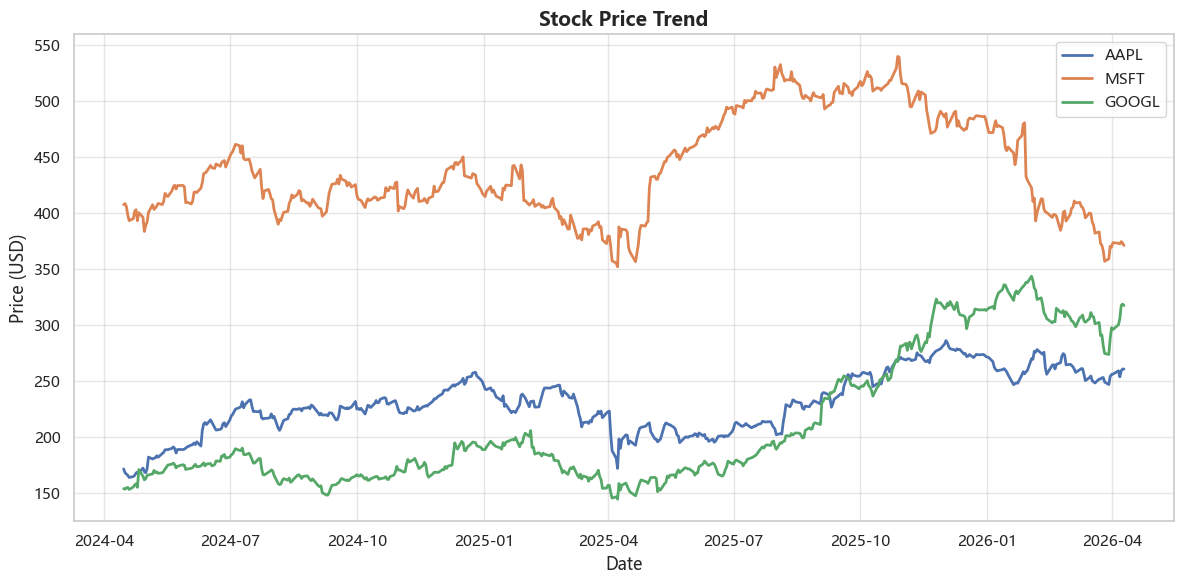

In [58]:
plt.figure(figsize=(12, 6))
for stock in stock_list:
    plt.plot(close_prices.index, close_prices[stock], label=stock, linewidth=2)

plt.title('Stock Price Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

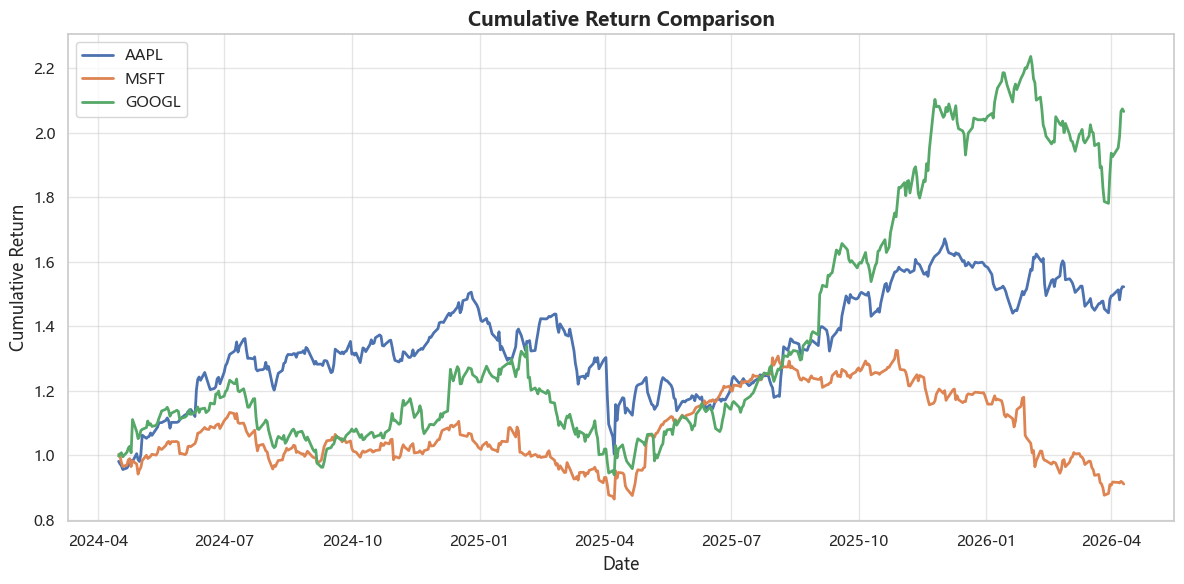

In [59]:
plt.figure(figsize=(12, 6))
for stock in stock_list:
    plt.plot(cumulative_returns.index, cumulative_returns[stock], label=stock, linewidth=2)

plt.title('Cumulative Return Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.tight_layout()
plt.savefig('figures/cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

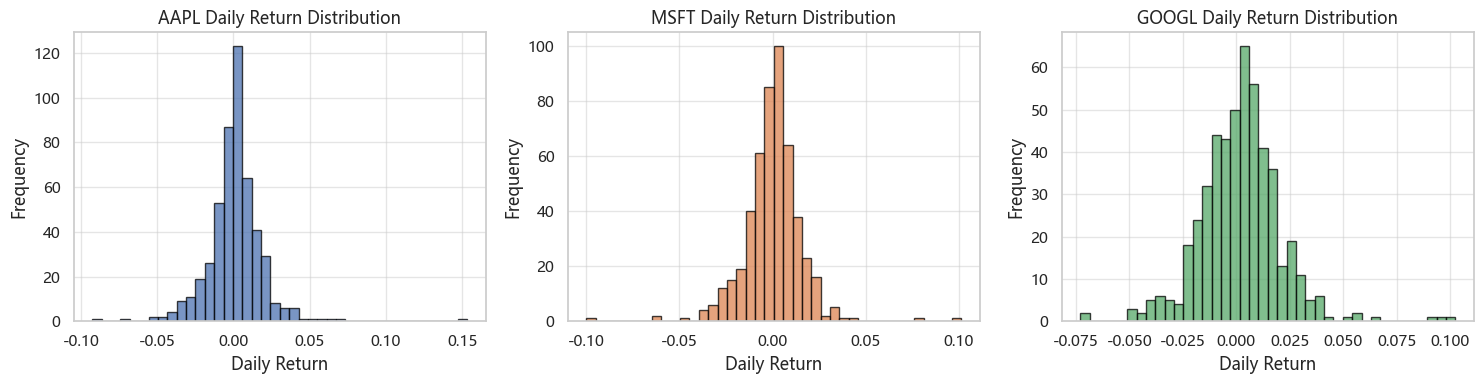

In [60]:
fig, axes = plt.subplots(1, len(stock_list), figsize=(5 * len(stock_list), 4))
if len(stock_list) == 1:
    axes = [axes]

for i, stock in enumerate(stock_list):
    axes[i].hist(returns[stock].dropna(), bins=40, edgecolor='black', alpha=0.75, color=f'C{i}')
    axes[i].set_title(f'{stock} Daily Return Distribution')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('figures/returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

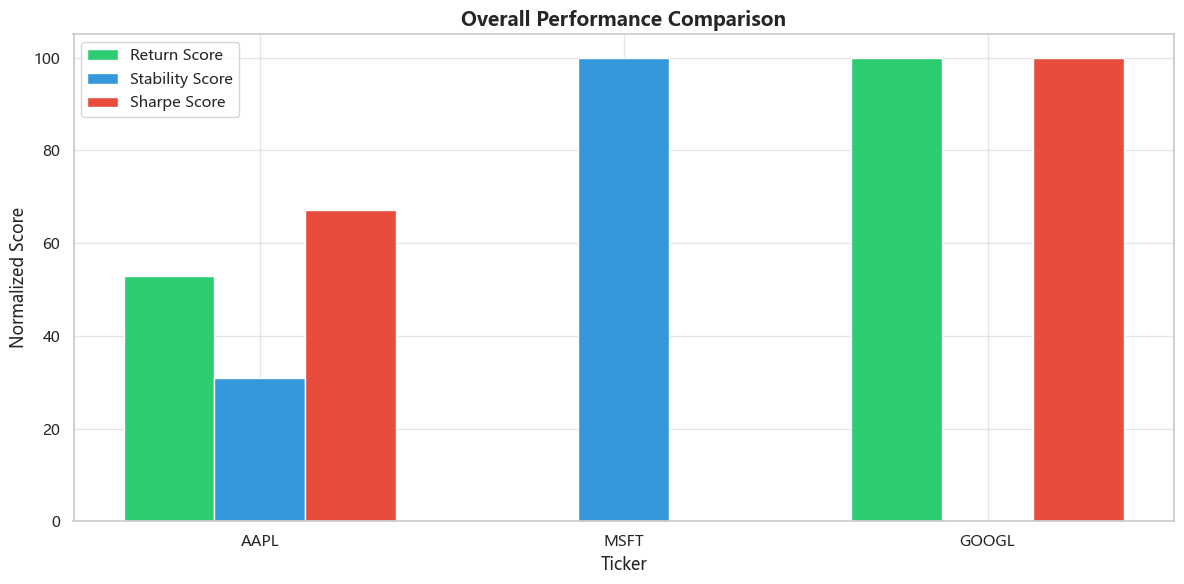

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(stock_list))
width = 0.25

ax.bar(x - width, returns_score.reindex(stock_list), width, label='Return Score', color='#2ecc71')
ax.bar(x, stability_score.reindex(stock_list), width, label='Stability Score', color='#3498db')
ax.bar(x + width, sharpe_score.reindex(stock_list), width, label='Sharpe Score', color='#e74c3c')

ax.set_title('Overall Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Ticker')
ax.set_ylabel('Normalized Score')
ax.set_xticks(x)
ax.set_xticklabels(stock_list)
ax.legend()
plt.tight_layout()
plt.savefig('figures/comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Results and Investment Insights

In [62]:
best_performer = total_returns.idxmax()
worst_performer = total_returns.idxmin()
lowest_volatility = annual_volatility.idxmin()
best_sharpe = sharpe_ratios.idxmax()

print('Summary of financial metrics:')
display(summary_df)

print('Key insights:')
print(f'1. Best return performance: {best_performer} ({total_returns[best_performer]:.2f}%)')
print(f'2. Lowest-risk stock: {lowest_volatility} (annualized volatility {annual_volatility[lowest_volatility]:.2f}%)')
print(f'3. Best risk-adjusted return: {best_sharpe} (Sharpe ratio {sharpe_ratios[best_sharpe]:.4f})')
print(f'4. Stock requiring close attention: {worst_performer} ({total_returns[worst_performer]:.2f}%)')
print('5. Investment suggestions:')
print(f'   Conservative investors may prioritize {lowest_volatility}.')
print(f'   Growth-oriented investors may prioritize {best_performer}.')
print(f'   Balanced investors may prioritize {best_sharpe}.')

Summary of financial metrics:


,Ticker,Current Price (USD),Total Return (%),Annualized Volatility (%),Sharpe Ratio
0,AAPL,260.48,52.21,28.31,0.8205
1,MSFT,370.87,-8.96,24.13,-0.1590
2,GOOGL,317.24,106.55,30.17,1.3008


Key insights:
1. Best return performance: GOOGL (106.55%)
2. Lowest-risk stock: MSFT (annualized volatility 24.13%)
3. Best risk-adjusted return: GOOGL (Sharpe ratio 1.3008)
4. Stock requiring close attention: MSFT (-8.96%)
5. Investment suggestions:
   Conservative investors may prioritize MSFT.
   Growth-oriented investors may prioritize GOOGL.
   Balanced investors may prioritize GOOGL.


## 7. Conclusion


1. Download stock price data from Yahoo Finance.
2. Handle missing values in the closing price series and ensure structural compatibility.
3. Calculate total return, annualized volatility, and the Sharpe ratio.
4. Produce charts for price trends, cumulative returns, return distributions, and overall comparisons.
5. Generate investment suggestions for different risk preferences based on the metrics.

Data source: Yahoo Finance API